## Image registration with help of corresponding points

Demonstrates how to use a fixed and a corresponding moving point set to help an image registration.

Suppose the moving image is rotated with respect to the fixed image. When the rotation is large, it may be helpful to add corresponding points to the fixed and the moving image.

In [240]:
import itk
import numpy as np
import math
import matplotlib.pyplot as plt

# Generates an itk.PointSet having the specified points.
def make_point_set(dimension: int, points: tuple):
    point_set = itk.PointSet[itk.UC, dimension].New()
    point_container = point_set.GetPoints().CastToSTLContainer()

    point_container.reserve(len(points))
    for point in points:
        point_container.push_back(point)

    return point_set

# Converts an itk.Point to a tuple.
def point_to_tuple(point):
    return tuple(coordinate for coordinate in point)

# Converts an itk.PointSet to a tuple of tuples.
def point_set_to_tuple(point_set):
    return tuple( point_to_tuple(point) for point in point_set.GetPoints().CastToSTLContainer() )

# Rotates the specified point around the specified center.
def rotate_point(point: tuple, center: tuple, rotation_angle: float):
    x = point[0] - center[0]
    y = point[1] - center[1]
    cos = math.cos(rotation_angle)
    sin = math.sin(rotation_angle)
    return (x * cos - y * sin + center[0], y * cos + x * sin + center[1])

# Rotates the specified points around the specified center.
def rotate_points(points: tuple, center: tuple, rotation_angle: float):
    return tuple( rotate_point(point, center, rotation_angle) for point in points )

In [241]:
# Plots the points from specified .itk.PointSet objects.
def plot_point_sets(image_size: tuple, point_sets: tuple, title: str):
    fig = plt.figure(figsize=(3, 3))
    fig.suptitle(title)  
    axes = plt.axes()
    axes.set_xlim(0, image_size[0])
    axes.set_ylim(0, image_size[1])
        
    for point_set in point_sets:
        index_range = range(0, point_set.GetNumberOfPoints())
        axes.scatter(
            x = [point_set.GetPoint(i)[0] for i in index_range],
            y = [point_set.GetPoint(i)[1] for i in index_range],
            s = 128
        )

    for point_set in point_sets:
        for i in range(0, point_set.GetNumberOfPoints()):
            point = point_set.GetPoint(i)
            plt.plot(point[0], point[1], color="yellow",  marker='$' + str(i + 1) + '$')

In [242]:
import math
image_size_value = 32
image_size = (image_size_value, image_size_value)
center = (image_size_value/2, image_size_value/2) 
dimension = len(image_size)
fixed_point1 = (10.0, 15.0)
fixed_point2 = (20.0, 15.0)
fixed_points = (fixed_point1, fixed_point2)
rotation_angle = math.pi/3.0
print("Rotation angle = ", rotation_angle, " radians")
moving_points = rotate_points(fixed_points, center, rotation_angle)
fixed_point_set = make_point_set(dimension,fixed_points)
moving_point_set = make_point_set(dimension, moving_points)

Rotation angle =  1.0471975511965976  radians


Fixed points:  ((10.0, 15.0), (20.0, 15.0))
Moving points:  ((13.866025403784437, 10.303847577293368), (18.86602540378444, 18.964101615137753))



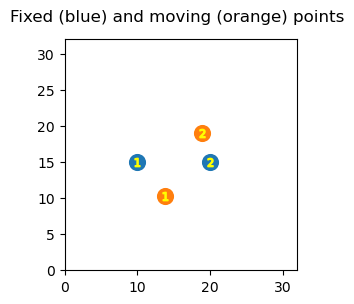

In [243]:
print('Fixed points: ', fixed_points)
print('Moving points: ', moving_points)
print()
plot_point_sets(image_size, (fixed_point_set, moving_point_set), 'Fixed (blue) and moving (orange) points')


In [244]:
def create_image(image_size):
    ImageType = itk.Image[itk.SS, len(image_size)]
    image = ImageType.New(regions=image_size)
    image.AllocateInitialized()
    return image 


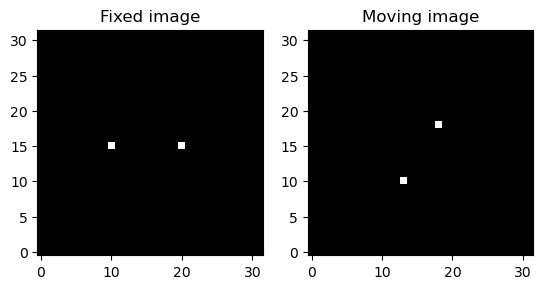

In [245]:
fixed_image = create_image(image_size)
moving_image = create_image(image_size)

for i in range(fixed_point_set.GetNumberOfPoints()):
    point = fixed_point_set.GetPoint(i)
    fixed_image.SetPixel((int(point[0]), int(point[1])), 1)
    point = moving_point_set.GetPoint(i)
    moving_image.SetPixel((int(point[0]), int(point[1])), 1)

fig = plt.figure()
ax1, ax2 = fig.subplots(1,2) 
ax1.set_title('Fixed image')
ax1.imshow(itk.GetArrayViewFromImage(fixed_image), cmap='binary_r', origin='lower')
ax2.set_title('Moving image')
ax2.imshow(itk.GetArrayViewFromImage(moving_image), cmap='binary_r', origin='lower')
plt.show()

Detected transformation (rotation, translation X, translation Y):  [ 1.03096548 -0.17190234 -0.81410688]
Transformed points:  ((12.930045127868652, 9.711021423339844), (18.06995391845703, 18.288978576660156))
Moving points:  ((13.866025403784437, 10.303847577293368), (18.86602540378444, 18.964101615137753))



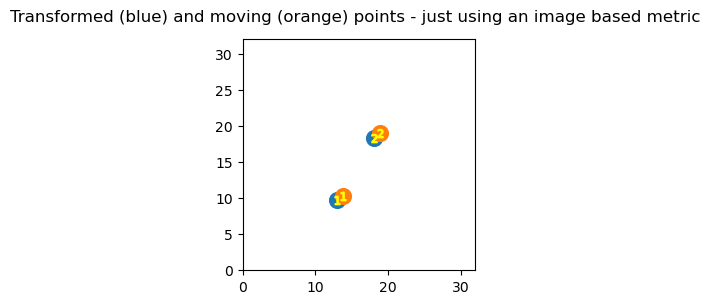

In [246]:
parameter_object = itk.ParameterObject.New()
parameter_object.SetParameterMap(
    {"ImageSampler": ("Full",),
    "AutomaticScalesEstimation": ("true",),
    "AutomaticTransformInitialization": ("true",),
    "MaximumNumberOfIterations": ("100",),
    "Metric": ("AdvancedNormalizedCorrelation",),
    "Optimizer": ("AdaptiveStochasticGradientDescent",),
    "Registration": ( "MultiMetricMultiResolutionRegistration",),
    "Transform": ("EulerTransform",)})

registration = itk.ElastixRegistrationMethod.New(
    fixed_image=fixed_image,
    moving_image=moving_image,
    parameter_object=parameter_object)
registration.Update()

transform = registration.GetNthTransform(0)
print('Detected transformation (rotation, translation X, translation Y): ', itk.GetArrayViewFromVnlVector(transform.GetParameters()))

transformed_point_set = itk.PointSet[itk.UC, dimension].New()

for i in range(0, fixed_point_set.GetNumberOfPoints()):
    transformed_point = transform.TransformPoint(fixed_point_set.GetPoint(i))
    transformed_point_set.SetPoint(i, transformed_point)

print('Transformed points: ', point_set_to_tuple(transformed_point_set))
print('Moving points: ', moving_points)
print()
plot_point_sets(image_size, (transformed_point_set, moving_point_set), 'Transformed (blue) and moving (orange) points - just using an image based metric')


Detected transformation (rotation, translation X, translation Y):  [ 1.04446659  0.65802753 -0.17687902]
Transformed points:  ((13.82735824584961, 10.316327095031738), (18.850990295410156, 18.962894439697266))
Moving points:  ((13.866025403784437, 10.303847577293368), (18.86602540378444, 18.964101615137753))



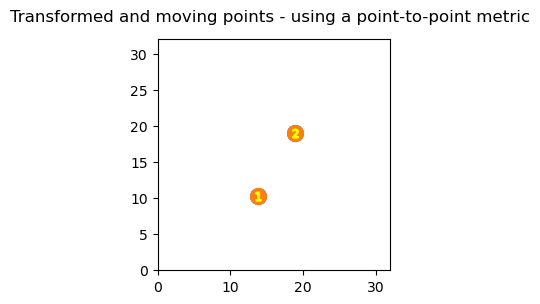

In [247]:
parameter_object.SetParameter("Metric", ("AdvancedNormalizedCorrelation", "CorrespondingPointsEuclideanDistanceMetric"))

registration = itk.ElastixRegistrationMethod.New(
    fixed_image=fixed_image,
    moving_image=moving_image,
    parameter_object=parameter_object,
    fixed_points=fixed_point_set.GetPoints(),
    moving_points=moving_point_set.GetPoints()
)
registration.Update()

transform = registration.GetNthTransform(0)
print('Detected transformation (rotation, translation X, translation Y): ', itk.GetArrayViewFromVnlVector(transform.GetParameters()))

transformed_point_set = itk.PointSet[itk.UC, dimension].New()

for i in range(0, fixed_point_set.GetNumberOfPoints()):
    transformed_point = transform.TransformPoint(fixed_point_set.GetPoint(i))
    transformed_point_set.SetPoint(i, transformed_point)

print('Transformed points: ', point_set_to_tuple(transformed_point_set))
print('Moving points: ', moving_points)
print()
plot_point_sets(image_size, (transformed_point_set, moving_point_set), 'Transformed and moving points - using a point-to-point metric')